In [1]:
import degirum as dg, mytools
import numpy as np
import cv2
from non_max_suppression import *

In [2]:
image_path = "ppl9.jpg"

In [3]:
class Yolov6FaceDetection(dg.postprocessor.DetectionResults):
    def __init__(self, *args, **kwargs): 
        super().__init__(*args, **kwargs)
        new_inference_results=[]
        for el in self._inference_results:
            prediction = el["data"]
            det = non_max_suppression_face_numpy(prediction, conf_thres=0.4, iou_thres=0.3, classes=None, agnostic=False, multi_label=False, max_det=300)
            for i,k in enumerate(det):
                result = {"bbox" : k[:4].tolist(), "category_id" : 0, "label" : "face", "score" : k[4], "landmarks" : [{"label" : 'LeftEye', "category_id" : 0, "landmark":k[6:8].tolist()},{"label" : 'RightEye', "category_id" : 1, "landmark":k[8:10].tolist()},{"label":'Nose',"category_id" : 2,"landmark":k[10:12].tolist()},{"label":'LipsleftCorner',"category_id" : 3,"landmark":k[12:14].tolist()},{"label":'LipsRightCorner',"category_id" : 4,"landmark":k[14:16].tolist()}]}
                box = result["bbox"]
                result["bbox"] = [
                    *self._conversion(*box[:2]),
                    *self._conversion(*box[2:]),
                ]
                for ldmks in result["landmarks"]:
                    ldmks["landmark"] = [*self._conversion(*ldmks["landmark"])]
                new_inference_results.append(result)

        self._inference_results = new_inference_results
        print (self._inference_results)
        

### Face detection model

In [4]:
# zoo = dg.connect_model_zoo("0.0.0.0:8778")
# model = zoo.load_model("yolo_v6n_face--512x512_float_openvino_cpu_1")
# model.custom_postprocessor = Yolov6FaceDetection
# # model.image_backend = 'pil'
# res = model("face.jpg")
# # model.overlay_show_probabilities = False
cloud_token = mytools.get_token() # get cloud API access token from env.ini file
cloud_zoo_url = mytools.get_cloud_zoo_url() # get cloud zoo URL from env.ini file
zoo = dg.connect(dg.CLOUD, cloud_zoo_url, cloud_token)
model = zoo.load_model("yolo_v6n_face--640x640_float_openvino_cpu_1")
model.image_backend = "pil"
model.custom_postprocessor = Yolov6FaceDetection

pre_img_shape =[model.model_info.InputH[0],model.model_info.InputW[0]]
res = model(image_path)

[{'bbox': [90.32417034770168, 54.82245869636535, 121.16458697651707, 94.79325771331787], 'category_id': 0, 'label': 'face', 'score': 0.9034740328788757, 'landmarks': [{'label': 'LeftEye', 'category_id': 0, 'landmark': [97.1871249176735, 70.84211440086365]}, {'label': 'RightEye', 'category_id': 1, 'landmark': [112.01785988031432, 70.3717605113983]}, {'label': 'Nose', 'category_id': 2, 'landmark': [104.30728816542515, 78.25046153068543]}, {'label': 'LipsleftCorner', 'category_id': 3, 'landmark': [97.83431566815044, 83.01485795974732]}, {'label': 'LipsRightCorner', 'category_id': 4, 'landmark': [112.53817365779433, 82.60489296913147]}]}]


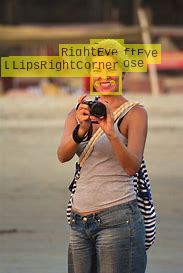

In [5]:
res.image_overlay

In [56]:
facebox = res.results[0]["bbox"]
facewidth, faceheight = (facebox[2] - facebox[0]), (facebox[3] - facebox[1])
facewidth,faceheight

(30.84041662881539, 39.97079901695252)

### Save the cropped face image using the bbox results

In [57]:
image =  cv2.imread(image_path)
crop = image[int(facebox[1]):int(facebox[1]+faceheight), int(facebox[0]):int(facebox[0]+facewidth)]
cropped_image_path = image_path.split(".")[0] +'_crop.jpg'
cv2.imwrite(cropped_image_path, crop)

True

### Landmarks regressor model

In [58]:
import degirum as dg
zoo_ = dg.connect_model_zoo("0.0.0.0:8778")
model_ = zoo_.load_model("landmarks_regression_retail--256x128_float_openvino_cpu_1")
model_.measure_time=True
model_.model_info.InputColorSpace 

In [60]:
res_= model_(cropped_image_path)
outputs=res_.results[0]["data"]

### Keypoints

In [61]:
left_eye_x, left_eye_y = int(outputs[0][0][0][0] * facewidth), int(outputs[0][1][0][0] * faceheight)
right_eye_x, right_eye_y = int(outputs[0][2][0][0] * facewidth), int(outputs[0][3][0][0] * faceheight)
nose_x, nose_y = int(outputs[0][4][0][0] * facewidth), int(outputs[0][5][0][0] * faceheight)
lip_left_corner_x, lip_left_corner_y = int(outputs[0][6][0][0] * facewidth), int(outputs[0][7][0][0] * faceheight)
lip_right_corner_x, lip_right_corner_y = int(outputs[0][8][0][0] * facewidth), int(outputs[0][9][0][0] * faceheight)

keypoints = [left_eye_x,left_eye_y,right_eye_x,right_eye_y,nose_x,nose_y,lip_left_corner_x,lip_left_corner_y,lip_right_corner_x,lip_right_corner_y]
print (keypoints)

[7, 16, 22, 15, 14, 23, 7, 29, 23, 28]


### Draw the landmarks

In [62]:
image_cropped =  cv2.imread(cropped_image_path)
for i in range(0,len(keypoints),2):
    cv2.circle(image_cropped, (keypoints[i],keypoints[i+1]),2,(0,0,255),-1)    

### Save the cropped image with 5 keypoints drawn

In [63]:
cv2.imwrite(cropped_image_path.split(".")[0]+'_output.jpg', image_cropped)

True